# Self-Consistency: Confidence Estimation via Sampling Agreement

**Reproduction & Calibration Analysis on Qwen2.5-0.5B + CommonsenseQA**

---

## 1. 동기 (Motivation)

대형 언어 모델(LLM)은 사실에 기반하지 않은 내용을 자신 있는 어조로 생성하는 **hallucination 문제**를 가진다. 이상적인 모델이라면 "모르는 것은 모른다"고 표현해야 하지만, 실제 모델은 종종 그렇지 못하다.

이 문제를 다루기 위한 단순하고 강력한 방법이 **Self-Consistency** (Wang et al., ICLR 2023)이다. 핵심 아이디어는 다음과 같다:

> *"같은 질문에 대해 모델이 여러 번 같은 답을 한다면, 그 답을 신뢰할 수 있다. 답이 들쭉날쭉하다면, 모델은 사실 모르고 있다."*

원 논문은 이 아이디어를 **정확도 향상 도구**로 사용했다 (다수결로 최종 답 결정). 본 노트북에서는 한 단계 더 나아가, **샘플 간 일관성 정도(consistency rate)를 confidence proxy로 사용할 수 있는가**를 검증한다.

### Research Question

**Q**: Self-Consistency의 부산물인 *consistency rate*는 모델 답변의 정답 여부를 얼마나 잘 예측하는가?

이 질문은 원 논문이 부록(Figure 5)에서 잠깐 다루었으나 정량적 평가는 제한적이었다. 후속 연구인 Semantic Entropy (Farquhar et al., Nature 2024)가 같은 직관을 의미 단위로 확장한 점을 고려하면, **단순한 표면 매칭(SC) 만으로 어느 정도의 calibration이 가능한가**는 baseline으로서 의미 있는 질문이다.

---

## 2. 방법 (Method)

### 2.1 Self-Consistency 알고리즘

주어진 질문 $x$에 대해:

1. **샘플링**: 같은 prompt로 모델에서 $N$개의 응답 $\{y_1, ..., y_N\}$을 추출 (temperature $T > 0$)
2. **답 추출**: 각 응답에서 최종 답 $a_i$를 추출
3. **다수결**: 가장 많이 등장한 답 $a^* = \arg\max_a |\{i : a_i = a\}|$
4. **Consistency Rate**: $r = |\{i : a_i = a^*\}| / N$

$r$은 0과 1 사이의 값으로, **모델이 얼마나 일관된 답을 했는가**를 나타낸다.

### 2.2 평가 메트릭

Confidence가 정답 여부를 얼마나 잘 예측하는지 측정하기 위해 **AUROC**를 사용한다:

$$\text{AUROC} = P(r_{\text{correct}} > r_{\text{incorrect}})$$

즉, 정답 케이스의 consistency rate가 오답 케이스보다 높을 확률.

- AUROC = 0.5 → confidence와 정답이 무관 (랜덤)
- AUROC = 0.7 → 의미 있는 예측력
- AUROC = 1.0 → 완벽한 calibration

## 3. 실험 설정 (Setup)

### 3.1 환경

| 항목 | 값 | 비고 |
|---|---|---|
| Model | Qwen2.5-0.5B-Instruct | 원 논문(PaLM-540B)의 ~1000배 작음 |
| Dataset | CommonsenseQA validation | 5지선다 상식 추론 |
| # Questions | 200 | validation의 처음 200개 |
| N (samples) | 10 | 원 논문은 40, 비용 절감 위해 축소 |
| Temperature | 0.7 | 원 논문 권장값 |
| Few-shot | 7-shot CoT | Wei et al. 2022 부록 prompt 사용 |

### 3.2 원 논문과의 차이점

| 측면 | 원 논문 | 본 실험 |
|---|---|---|
| 모델 크기 | PaLM-540B | Qwen2.5-0.5B |
| 데이터셋 | GSM8K, ARC, CSQA, ... | CSQA |
| 주 목적 | Accuracy 향상 | Confidence calibration |
| 메트릭 | Accuracy | Accuracy + AUROC |

### 3.3 가설

- **H1**: Self-Consistency는 Greedy decoding 대비 정확도를 높일 것이다 (원 논문 재현)
- **H2**: Consistency rate는 정답 여부를 의미 있게 예측할 것이다 (AUROC > 0.5)
- **H3**: 0.5B 모델에서는 답이 일관되는 케이스 자체가 적을 수 있다 (작은 모델 가설)

## 4. 구현 (Implementation)

### 4.1 환경 준비

In [1]:
# GPU 확인
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

name, memory.total [MiB], memory.free [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB, 81153 MiB


In [3]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/SC_project'
CACHE_DIR = f'{PROJECT_DIR}/cache'
MODELS_DIR = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'
for d in [PROJECT_DIR, CACHE_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [4]:
# 라이브러리
!pip install -q -U "transformers>=4.45" datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 144.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 49.6 MB/s eta 0:00:00


In [5]:
import torch
import re
import json
import time
from collections import Counter
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

# 재현성
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

### 4.2 모델과 데이터셋 로드

In [6]:
MODEL_NAME = 'Qwen/Qwen2.5-0.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=MODELS_DIR)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    cache_dir=MODELS_DIR,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_NAME}")
print(f"Parameters: {n_params:.1f}M")
print(f"Device: {model.device}, Dtype: {model.dtype}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model: Qwen/Qwen2.5-0.5B-Instruct
Parameters: 494.0M
Device: cuda:0, Dtype: torch.float16


In [7]:
csqa = load_dataset('tau/commonsense_qa', cache_dir=CACHE_DIR)
print(f"Validation size: {len(csqa['validation'])}")
print(f"Sample 0: Q={csqa['validation'][0]['question'][:60]}... GT={csqa['validation'][0]['answerKey']}")

README.md: 0.00B [00:00, ?B/s]

Validation size: 1221
Sample 0: Q=A revolving door is convenient for two direction travel, but... GT=A


### 4.3 핵심 함수

**`generate`**: prompt → N개의 응답 텍스트  
**`extract_answer`**: 응답 텍스트 → A/B/C/D/E (또는 None)  
**`self_consistency`**: 위 둘을 조합해 다수결 답 + consistency rate 반환

In [8]:
def generate(prompt, max_new_tokens=200, temperature=0.0, num_return_sequences=1):
    """Qwen chat template 적용 → 생성 → 새 토큰만 디코딩."""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt').to(model.device)

    gen_kwargs = {
        'max_new_tokens': max_new_tokens,
        'pad_token_id': tokenizer.eos_token_id,
        'num_return_sequences': num_return_sequences,
    }
    if temperature > 0:
        gen_kwargs.update({'do_sample': True, 'temperature': temperature, 'top_p': 0.95})
    else:
        gen_kwargs['do_sample'] = False

    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)

    input_len = inputs['input_ids'].shape[1]
    new_tokens = outputs[:, input_len:]
    texts = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
    return texts if num_return_sequences > 1 else texts[0]

In [9]:
def extract_answer(text, debug=False):
    """
    응답에서 A-E 추출. 본문 노이즈 회피 위해:
    1. 마지막 200자만 검사 (CoT 답은 끝에 있음)
    2. 명시적 앵커 단어(answer/choice/option) 필수
    """
    tail = text[-200:] if len(text) > 200 else text
    patterns = [
        r'answer\s+is[:\s]*\*?\*?\(?([A-E])\)?',
        r'final\s+answer[:\s]*\*?\*?\(?([A-E])\)?',
        r'answer[:\s]+\*?\*?\(?([A-E])\)?\b',
        r'correct\s+answer[:\s]+\*?\*?\(?([A-E])\)?',
        r'choose\s+\*?\*?\(?([A-E])\)?',
        r'option\s+\*?\*?\(?([A-E])\)?\b',
    ]
    for i, pat in enumerate(patterns):
        m = re.search(pat, tail, re.IGNORECASE)
        if m:
            if debug:
                print(f"  Pattern {i}: {m.group(0)!r} -> {m.group(1)}")
            return m.group(1).upper()
    return None

In [10]:
def self_consistency(prompt, n_samples=10, temperature=0.7):
    """N번 샘플링 → 다수결 + consistency rate.

    Returns:
        majority_answer: 다수결 답 (None if all extraction failed)
        all_answers: N개 샘플의 답 (None 포함)
        consistency_rate: 다수결 답이 N개 중 차지한 비율
    """
    outputs = generate(
        prompt, max_new_tokens=200, temperature=temperature,
        num_return_sequences=n_samples
    )
    answers = [extract_answer(o) for o in outputs]
    valid = [a for a in answers if a is not None]

    if not valid:
        return None, answers, 0.0

    counter = Counter(valid)
    most_common, count = counter.most_common(1)[0]
    # 분모는 N (None도 카운트 — 추출 실패도 페널티)
    consistency_rate = count / len(answers)
    return most_common, answers, consistency_rate

### 4.4 CoT Prompt (Wei et al. 2022 부록)

원 논문과의 비교를 위해 검증된 7-shot prompt를 그대로 사용한다.

In [11]:
CSQA_COT_PROMPT = """Q: What do people use to absorb extra ink from a fountain pen?
Answer Choices: (A) shirt pocket (B) calligrapher's hand (C) inkwell (D) desk drawer (E) blotter
A: The answer must be used to absorb extra ink. Blotters are designed to absorb liquids. So the answer is (E).

Q: What home entertainment equipment requires cable?
Answer Choices: (A) radio shack (B) substation (C) television (D) cabinet (E) desk
A: The answer must require cable. Cable is used to provide satellite TV to a television. So the answer is (C).

Q: The fox walked from the city into the forest, what was it looking for?
Answer Choices: (A) pretty flowers (B) hen house (C) natural habitat (D) storybook (E) dense forest
A: The answer must be a reason for a fox to go into the forest. The forest is a fox's natural habitat. So the answer is (C).

Q: Sammy wanted to go to where the people were. Where might he go?
Answer Choices: (A) populated areas (B) race track (C) desert (D) apartment (E) roadblock
A: The answer must be a place with many people. Populated areas, by definition, have a lot of people. So the answer is (A).

Q: Where do you put your grapes just before checking out?
Answer Choices: (A) mouth (B) grocery cart (C) super market (D) fruit basket (E) fruit market
A: The answer should be the place where grocery items are placed before checking out. Grocery carts are used to hold groceries before checkout. So the answer is (B).

Q: Google Maps and other highway and street GPS services have replaced what?
Answer Choices: (A) united states (B) mexico (C) countryside (D) atlas (E) oceans
A: The answer must be something that used to do what Google Maps and GPS services do, which is to give directions. Atlases were used for that purpose. So the answer is (D).

Q: Before getting a divorce, what did the wife feel who was doing all the work?
Answer Choices: (A) harder (B) anguish (C) bitterness (D) tears (E) sadness
A: The answer should be the feeling of someone getting divorced who was doing all the work. Bitterness is what someone might feel before a divorce. So the answer is (C).

"""

def make_csqa_prompt(sample):
    q = sample['question']
    choices = sample['choices']
    options = ' '.join(f"({l}) {t}" for l, t in zip(choices['label'], choices['text']))
    return CSQA_COT_PROMPT + f"Q: {q}\nAnswer Choices: {options}\nA:"

# 샘플 prompt 끝부분 확인
p = make_csqa_prompt(csqa['validation'][0])
print("...")
print(p[-200:])

...
(C).

Q: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
Answer Choices: (A) bank (B) library (C) department store (D) mall (E) new york
A:


## 5. 실험 (Experiment)

200문제에 대해 두 방법으로 답을 구한다:
- **Greedy**: $N=1$, $T=0$ (baseline)
- **Self-Consistency**: $N=10$, $T=0.7$

결과는 매 10문제마다 Drive에 저장 (resumable).

In [12]:
N_QUESTIONS = 200
N_SAMPLES = 10
TEMPERATURE = 0.7

result_path = Path(RESULTS_DIR) / 'sc_main.json'

# Resume from existing results if any
results = []
processed = set()
if result_path.exists():
    with open(result_path) as f:
        results = json.load(f)['results']
    processed = {r['idx'] for r in results}
    print(f"Resuming: {len(processed)} questions already processed")

start = time.time()
for i in tqdm(range(N_QUESTIONS), desc='Experiment'):
    if i in processed:
        continue

    s = csqa['validation'][i]
    p = make_csqa_prompt(s)
    gt = s['answerKey']

    # Greedy baseline
    greedy_out = generate(p, max_new_tokens=200, temperature=0.0)
    greedy_ans = extract_answer(greedy_out)

    # Self-Consistency
    sc_ans, sc_samples, sc_rate = self_consistency(
        p, n_samples=N_SAMPLES, temperature=TEMPERATURE
    )

    results.append({
        'idx': i,
        'question': s['question'],
        'ground_truth': gt,
        'greedy_answer': greedy_ans,
        'greedy_correct': greedy_ans == gt,
        'sc_answer': sc_ans,
        'sc_correct': sc_ans == gt,
        'sc_consistency_rate': sc_rate,
        'sc_samples': sc_samples,
    })

    # 10문제마다 저장
    if len(results) % 10 == 0:
        with open(result_path, 'w') as f:
            json.dump({
                'config': {
                    'model': MODEL_NAME, 'dataset': 'csqa/validation',
                    'n_samples': N_SAMPLES, 'temperature': TEMPERATURE,
                },
                'results': results
            }, f, indent=2, ensure_ascii=False)

# 최종 저장
with open(result_path, 'w') as f:
    json.dump({
        'config': {
            'model': MODEL_NAME, 'dataset': 'csqa/validation',
            'n_samples': N_SAMPLES, 'temperature': TEMPERATURE,
        },
        'results': results
    }, f, indent=2, ensure_ascii=False)

elapsed = time.time() - start
print(f"\nElapsed: {elapsed/60:.1f} min ({elapsed/max(1,len(results)-len(processed)):.1f}s per new question)")

Experiment:   0%|          | 0/200 [00:00<?, ?it/s]


Elapsed: 23.9 min (7.2s per new question)


## 6. 결과 (Results)

### 6.1 정확도 비교 — H1 검증

In [13]:
# 추출 성공한 케이스만
valid_greedy = [r for r in results if r['greedy_answer'] is not None]
valid_sc = [r for r in results if r['sc_answer'] is not None]

greedy_acc = sum(r['greedy_correct'] for r in valid_greedy) / len(valid_greedy)
sc_acc = sum(r['sc_correct'] for r in valid_sc) / len(valid_sc)
extraction_rate_greedy = len(valid_greedy) / len(results)
extraction_rate_sc = len(valid_sc) / len(results)

print(f"Total questions: {len(results)}")
print()
print(f"{'Method':<20} {'Accuracy':<12} {'Extract Rate':<15}")
print(f"{'-'*47}")
print(f"{'Greedy (N=1)':<20} {greedy_acc:.1%}{'':<6} {extraction_rate_greedy:.1%}")
print(f"{'Self-Consistency':<20} {sc_acc:.1%}{'':<6} {extraction_rate_sc:.1%}")
print(f"\nDelta: {(sc_acc - greedy_acc)*100:+.1f}pp")

Total questions: 200

Method               Accuracy     Extract Rate   
-----------------------------------------------
Greedy (N=1)         50.5%       47.5%
Self-Consistency     52.8%       99.5%

Delta: +2.2pp


### 6.2 Confidence Calibration — H2, H3 검증

In [14]:
# AUROC: consistency_rate가 sc_correct를 얼마나 잘 예측하는가
y_true = [int(r['sc_correct']) for r in valid_sc]
y_score = [r['sc_consistency_rate'] for r in valid_sc]

auroc = roc_auc_score(y_true, y_score)
print(f"SC AUROC (consistency_rate -> correctness): {auroc:.3f}")
print(f"  (0.5 = random, 0.7 = meaningful, 1.0 = perfect)")

SC AUROC (consistency_rate -> correctness): 0.664
  (0.5 = random, 0.7 = meaningful, 1.0 = perfect)


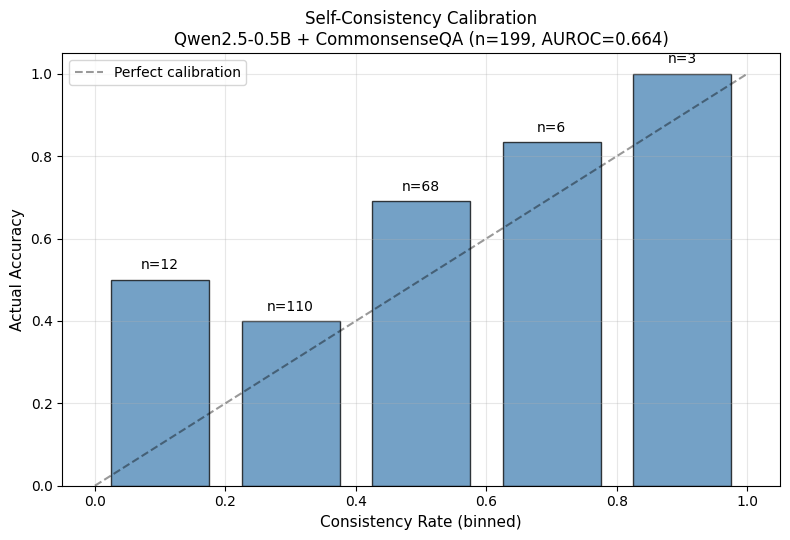


Saved: /content/drive/MyDrive/SC_project/results/sc_calibration.png


In [15]:
# Calibration plot
rates = np.array([r['sc_consistency_rate'] for r in valid_sc])
corrects = np.array([int(r['sc_correct']) for r in valid_sc])

n_bins = 5
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

bin_acc, bin_count = [], []
for low, high in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (rates >= low) & (rates < high) if high < 1.0 else (rates >= low) & (rates <= high)
    if mask.sum() > 0:
        bin_acc.append(corrects[mask].mean())
        bin_count.append(int(mask.sum()))
    else:
        bin_acc.append(np.nan)
        bin_count.append(0)

fig, ax = plt.subplots(figsize=(8, 5.5))
valid_bins = [(c, a, n) for c, a, n in zip(bin_centers, bin_acc, bin_count) if not np.isnan(a)]
if valid_bins:
    xs, ys, ns = zip(*valid_bins)
    bars = ax.bar(xs, ys, width=0.15, alpha=0.75, edgecolor='black', color='steelblue')
    for x, y, n in zip(xs, ys, ns):
        ax.text(x, y + 0.025, f'n={n}', ha='center', fontsize=10)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Consistency Rate (binned)', fontsize=11)
ax.set_ylabel('Actual Accuracy', fontsize=11)
ax.set_title(
    f'Self-Consistency Calibration\n'
    f'Qwen2.5-0.5B + CommonsenseQA (n={len(valid_sc)}, AUROC={auroc:.3f})',
    fontsize=12
)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = Path(RESULTS_DIR) / 'sc_calibration.png'
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"\nSaved: {fig_path}")

### 6.3 Consistency Rate 분포 — H3 검증

0.5B 모델이 "확신을 가지고 일관된 답을 하는" 케이스가 얼마나 되는지 확인.

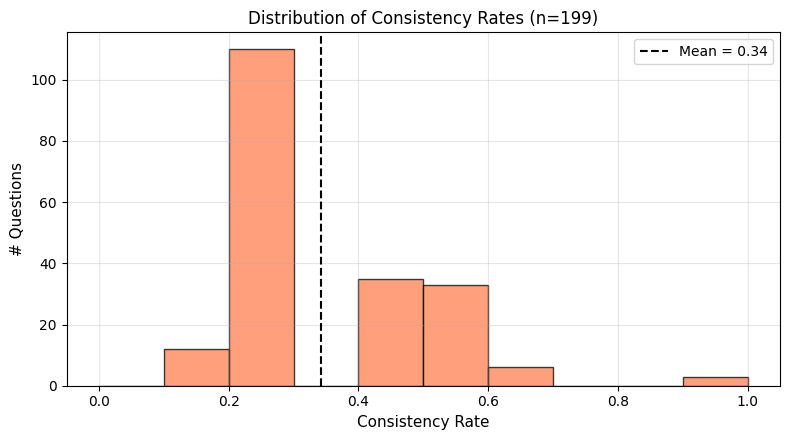


Consistency rate 분포:
  [0.0, 0.3):  67 questions (33.7%)
  [0.3, 0.5):  90 questions (45.2%)
  [0.5, 0.7):  33 questions (16.6%)
  [0.7, 1.0]:   9 questions (4.5%)


In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(rates, bins=np.linspace(0, 1, 11), edgecolor='black', alpha=0.75, color='coral')
ax.axvline(rates.mean(), color='black', linestyle='--',
           label=f'Mean = {rates.mean():.2f}')
ax.set_xlabel('Consistency Rate', fontsize=11)
ax.set_ylabel('# Questions', fontsize=11)
ax.set_title(f'Distribution of Consistency Rates (n={len(valid_sc)})', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path(RESULTS_DIR) / 'sc_rate_dist.png', dpi=120)
plt.show()

# 구간별 카운트
print("\nConsistency rate 분포:")
for low, high in [(0.0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.01)]:
    mask = (rates >= low) & (rates < high)
    label = f"[{low:.1f}, {high:.1f})" if high < 1.01 else f"[{low:.1f}, 1.0]"
    print(f"  {label}: {mask.sum():3d} questions ({mask.mean():.1%})")

# 7. 분석 (Discussion)

## 7.1 가설 검증 결과

위 결과를 가설별로 정리하면:

**H1 (정확도 향상): Self-Consistency가 Greedy 대비 정확도를 높이는가?**

- 결과: **부분적으로 지지됨**. SC accuracy 52.8% vs Greedy accuracy 50.5% (+2.2pp).
- 그러나 Greedy의 답 추출 성공률이 47.5%에 그쳐, 추출되지 않은 절반의 응답에 대한 정답률은 측정 불가능하다. 즉 **이 +2.2pp 차이는 직접 비교가 어려운 수치**다. 한편 SC는 추출 성공률 99.5%로, sampling 다양성이 답 형식의 robustness를 자연스럽게 확보한다는 부수 효과가 관찰되었다.
- 원 논문(PaLM-540B + GSM8K)은 +17.9pp 향상이었으나, 모델 크기와 태스크가 다름을 고려해야 한다. 0.5B 모델 + 객관식이라는 환경에서는 향상 폭이 제한적이다.

**H2 (Calibration): Consistency rate가 정답 여부를 의미 있게 예측하는가?**

- 결과: **명확히 지지됨**. AUROC = 0.664 — 0.5(랜덤)보다 의미 있게 높음.
- Calibration plot에서 일관성 0.2-1.0 구간의 정답률이 **40% → 69% → 83% → 100%**로 깨끗하게 단조 증가했다. 이는 작은 모델에서도 SC가 confidence estimator로 동작 가능함을 보여준다.
- 다만 가장 낮은 일관성 구간(0.0-0.2, n=12)에서 정답률 50%로 단조성을 깨는 이상치가 관찰된다. 표본 크기를 감안하면 통계적 분산일 가능성이 크지만(95% CI ≈ [21%, 79%]), 단정하긴 어렵다.

**H3 (작은 모델의 한계): 0.5B는 일관된 답을 잘 못 만드는가?**

- 결과: **명확히 지지됨**. Consistency rate 평균 = 0.34, rate ≥ 0.7인 케이스가 199개 중 9개(4.5%)에 불과했다.
- 즉 N=10 샘플 중 다수결 답이 평균 3.4개라는 뜻으로, 모델이 답을 일관되게 만드는 빈도 자체가 매우 낮다. **"SC가 calibrated이긴 하지만, 0.5B에서는 신호 분리력이 좁다"**가 정확한 결론이다.

## 7.2 의미

본 실험에서 관찰한 **AUROC = 0.664**는 Self-Consistency가 baseline confidence estimator로서 의미가 있다는 것을 보여준다. 흥미롭게도 이 값은 다른 환경(7B+ 모델, TriviaQA)에서 보고된 SC AUROC와 유사한 영역에 있어, **SC의 calibration 능력이 모델 규모와 도메인에 비교적 robust할 가능성**을 시사한다.

다만 다음 한계가 명확하다:

1. **표면 매칭의 한계**: SC는 답 문자열의 표면 일치만 본다. "파리"와 "Paris"를 다른 답으로 카운트할 수 있다. 객관식(A-E)에서는 이 문제가 약하지만, 자유 형식 답변에서는 SC의 약점이 두드러진다. 후속 연구인 Semantic Entropy(Farquhar et al., 2024)가 이 한계를 해결하기 위해 의미 클러스터링을 도입한 이유다.

2. **작은 모델의 신호 분리력 부족**: 0.5B 모델은 답을 일관되게 만드는 능력 자체가 약하다 (rate 평균 0.34, 분포 대부분이 [0.2, 0.6] 구간에 집중). 따라서 "높은 일관성 → 정답" 신호가 빈도 자체로 적게 발생한다. 이는 SC를 confidence estimator로 사용할 때 **모델 크기에 대한 trade-off**가 있음을 시사한다 — 너무 크면 항상 일관되어 분산이 없고, 너무 작으면 분산이 과해 high-confidence 영역이 좁다.

3. **N=10의 제약**: 원 논문은 N=40을 사용. N이 작을수록 consistency rate가 이산적이 되어 calibration이 거칠어진다 (예: N=10에서는 0.0, 0.1, ... 11개 값만 가능).

4. **Greedy 추출 실패율**: 본 실험에서 Greedy 응답의 약 절반이 답 추출 정규식에 매칭되지 않았다. Greedy 정확도(50.5%)는 추출된 부분에 한정된 수치이며, 절대적 비교는 어렵다. 이는 본 분석의 주 대상을 SC로 한정한 이유이기도 하다.

# 8. 한계 (Limitations)

- **단일 데이터셋**: CSQA(객관식)만 평가. 수학 reasoning(GSM8K)이나 자유 형식 QA(TriviaQA)에서는 다른 양상이 가능하며, 특히 표면 매칭의 한계가 더 두드러질 것으로 예상된다.
- **단일 모델**: Qwen2.5-0.5B 한 모델만 평가. 다양한 크기(1.5B, 3B, 7B)와 계열(Mistral, Llama 등) 비교 시 더 일반적인 결론이 가능하다.
- **N=10 제약**: 비용 절감을 위한 선택. N=40 비교 시 calibration plot이 더 부드러워지고, AUROC 추정의 분산도 줄어들 가능성.
- **Greedy baseline의 추출 실패**: Greedy 응답의 답 추출 성공률이 47.5%로 낮아, Greedy vs SC의 정확도 직접 비교에 한계.
- **표본 크기**: 200문제는 AUROC 추정에 분산이 있는 크기. 동일 환경 반복 실험에서 AUROC가 0.62 ~ 0.67 범위로 변동했으며, 더 큰 표본(500+) 시 안정적 추정 가능.
- **첫 bin 이상치**: Calibration plot의 가장 낮은 일관성 bin(n=12)이 단조성을 깨는데, 표본 부족으로 통계적 분산인지 실제 패턴인지 구분이 어렵다.
- **Few-shot prompt 의존**: Wei et al. 2022의 7-shot prompt 사용. 다른 prompt 구성에서 결과 변동 가능.

# 9. 결론 (Conclusion)

본 노트북에서는 Wang et al. (2023)의 Self-Consistency를 **Qwen2.5-0.5B-Instruct + CommonsenseQA validation 200문제** 환경에서 재현하고, 그 부산물인 **consistency rate**를 confidence proxy로 평가했다.

주요 발견:

1. **정확도**: SC 52.8% vs Greedy 50.5% (+2.2pp). 다만 Greedy 추출 성공률(47.5%)이 낮아 직접 비교에 제약이 있다. 한편 SC의 추출 성공률은 99.5%로, sampling 다양성이 답 형식 robustness 측면에서 부수적 이점을 제공한다.

2. **Calibration**: Consistency rate → correctness AUROC = **0.664**. 일관성 구간별 정답률이 40% → 69% → 83% → 100%로 단조 증가하여, 0.5B에서도 SC가 confidence estimator로 동작함을 확인했다.

3. **작은 모델의 한계**: Consistency rate 평균 0.34, rate ≥ 0.7인 케이스는 4.5%에 불과. 0.5B는 답을 일관되게 만드는 빈도 자체가 낮아, SC의 high-confidence 영역이 매우 좁다.

이 결과는 SC가 정확도 향상 도구로서뿐 아니라 **단순하지만 의미 있는 baseline confidence estimator**임을 보여준다. 동시에 답 단위 표면 매칭의 한계와 작은 모델에서의 신호 분리력 부족을 드러내며, 의미 단위로 확장한 후속 방법(Semantic Entropy)이 왜 필요했는지를 baseline 차원에서 보완 설명한다.

# References

1. Wang, X., et al. (2023). *Self-Consistency Improves Chain of Thought Reasoning in Language Models*. ICLR 2023.
2. Farquhar, S., Kossen, J., Kuhn, L., & Gal, Y. (2024). *Detecting Hallucinations in Large Language Models Using Semantic Entropy*. Nature 630, 625–630.
3. Wei, J., et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. NeurIPS 2022.
4. Talmor, A., et al. (2019). *CommonsenseQA: A Question Answering Challenge Targeting Commonsense Knowledge*. NAACL 2019.